In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, accuracy_score, log_loss, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap

In [2]:
#x_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/x_data.csv')
x_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/feature_df_2.csv')
y_data = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/y_data_rms.csv')

In [19]:
x_df = pd.read_csv('/Users/rasmus/Desktop/Fysik/AppliedML2026/AppMLFinalProject/feature_df_2.csv')

df = x_df.merge(y_data[['source_file', 'bottom_rms']], on='source_file').reset_index(drop=True)

df = df.dropna(subset=['bottom_rms'])

X = df.drop(columns=['source_file', 'bottom_rms'])
y = df['bottom_rms']

train_rem_idx = int(len(X) * 0.8) # 80% for training, 20% for validation and testing
val_test_idx = int(len(X) * 0.9) # 10% for validation, 10% for testing (from the remaining 20%)

X_train = X.iloc[:train_rem_idx]
X_val = X.iloc[train_rem_idx:val_test_idx]
X_test = X.iloc[val_test_idx:]

y_train = y.iloc[:train_rem_idx]
y_val = y.iloc[train_rem_idx:val_test_idx]
y_test = y.iloc[val_test_idx:]

In [20]:
def objective(trial):
    params = {
        "n_estimators": 5000,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),

        "gamma": trial.suggest_float("gamma", 0, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
    }
    
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    return mse

import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

[I 2026-06-06 14:25:40,551] A new study created in memory with name: no-name-233f314a-205a-489b-8293-47aa2a08972a
[I 2026-06-06 14:25:40,734] Trial 0 finished with value: 0.0005890257427850467 and parameters: {'max_depth': 8, 'learning_rate': 0.010463238748384302, 'subsample': 0.7287055179555694, 'colsample_bytree': 0.6718110370141253, 'min_child_weight': 14, 'gamma': 8.302878157199755, 'reg_alpha': 1.1020004864640666e-08, 'reg_lambda': 0.2592975462500241}. Best is trial 0 with value: 0.0005890257427850467.
[I 2026-06-06 14:25:40,862] Trial 1 finished with value: 0.0005890248771073912 and parameters: {'max_depth': 7, 'learning_rate': 0.0014033153378359775, 'subsample': 0.855271943539545, 'colsample_bytree': 0.9898254816256778, 'min_child_weight': 3, 'gamma': 4.323218518339722, 'reg_alpha': 0.00033263069651097064, 'reg_lambda': 9.61391643559562e-07}. Best is trial 1 with value: 0.0005890248771073912.
[I 2026-06-06 14:25:41,134] Trial 2 finished with value: 0.0005771682928033835 and para

In [33]:
#opt_params = {'n_estimators': 5000, 'max_depth': 10, 'learning_rate': 0.01525803171352834, 'subsample': 0.9361080329155063, 'colsample_bytree': 0.8774494819985844, 
#              'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', "random_state": 42}

opt_params = {'n_estimators': 5000, 'max_depth': 2, 'learning_rate': 0.015530627048745466, 'subsample': 0.7731651782531278, 'colsample_bytree': 0.7396227216381265, 'min_child_weight': 9, 'gamma': 0.024303918616681602, 'reg_alpha': 9.549875969413823e-05, 'reg_lambda': 4.166753511881032e-06}

final_model = xgb.XGBRegressor(**opt_params, early_stopping_rounds=70)
final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)
y_pred_val = final_model.predict(X_val)
y_pred_test = final_model.predict(X_test)

print("Dummy R2:", r2_score(y_val, dummy.predict(X_val)))
print("Model R2 (val):", r2_score(y_val, y_pred_val))
print("Model R2 (test):", r2_score(y_test, y_pred_test))

print("Dummy MAE:", mean_absolute_error(y_val, dummy.predict(X_val)))
print("Model MAE (val):", mean_absolute_error(y_val, y_pred_val))
print("Model MAE (test):", mean_absolute_error(y_test, y_pred_test))

Dummy R2: -0.00012899893564211062
Model R2 (val): 0.1319457051247802
Model R2 (test): 0.20967933298947783
Dummy MAE: 0.018940237953174045
Model MAE (val): 0.0180752590761456
Model MAE (test): 0.018971396192133495


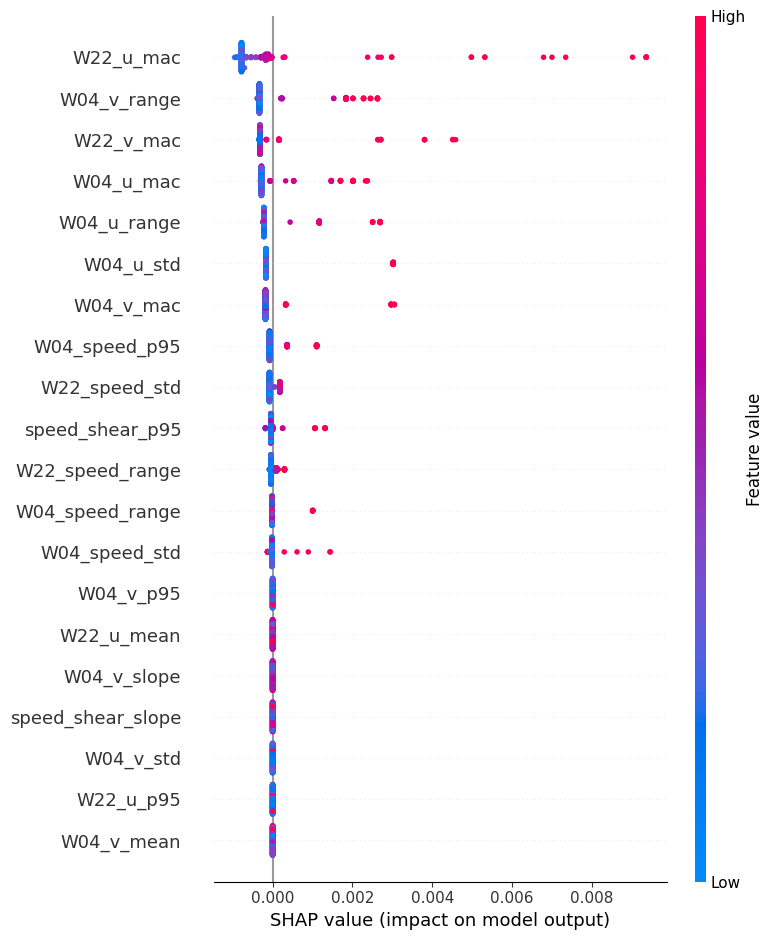

In [34]:
shap_values_final = shap.TreeExplainer(final_model).shap_values(X_val)
shap.summary_plot(shap_values_final, X_val, plot_type="dot")

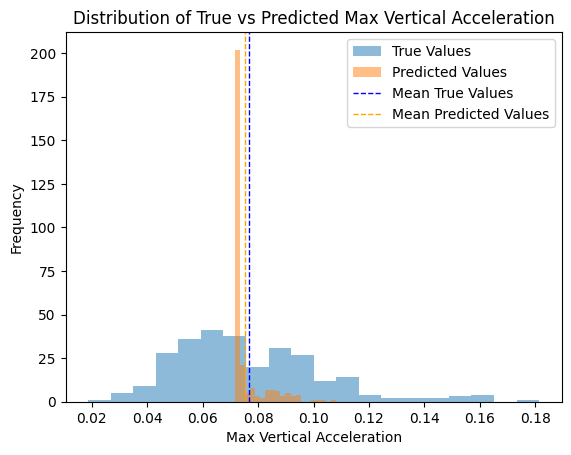

In [35]:
plt.hist(y_test, bins=20, alpha=0.5, label='True Values')
plt.hist(y_pred_test, bins=20, alpha=0.5, label='Predicted Values')
plt.xlabel('Max Vertical Acceleration')
plt.ylabel('Frequency')
plt.title('Distribution of True vs Predicted Max Vertical Acceleration')
plt.axvline(np.mean(y_test), color='blue', linestyle='dashed', linewidth=1, label='Mean True Values')
plt.axvline(np.mean(y_pred_test), color='orange', linestyle='dashed', linewidth=1, label='Mean Predicted Values')
plt.legend()
plt.show()

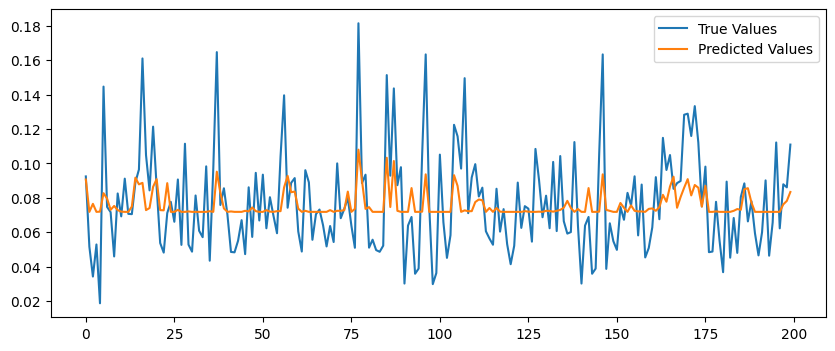

In [38]:
x_axis = np.arange(len(y_test))
plt.figure(figsize=(10,4))
plt.plot(x_axis[:200], y_test[:200], label='True Values')
plt.plot(x_axis[:200], y_pred_test[:200], label='Predicted Values')
plt.legend()
plt.show()

In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_values_final).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

top_features = shap_importance[:13]



            feature  mean_abs_shap
17        W22_u_mac       0.000943
9       W04_v_range       0.000558
23        W22_v_mac       0.000451
5         W04_u_mac       0.000420
3       W04_u_range       0.000403
1         W04_u_std       0.000382
11        W04_v_mac       0.000306
26    W04_speed_p95       0.000157
30    W22_speed_std       0.000106
36  speed_shear_p95       0.000097
32  W22_speed_range       0.000062
27  W04_speed_range       0.000043
25    W04_speed_std       0.000040


In [ ]:
def objective_top(trial):
    params = {
        "n_estimators": 5000,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        #"min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
#
        #"gamma": trial.suggest_float("gamma", 0, 10),
        #"reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        #"reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 42,
    }
    
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_val)

    return sklearn.metrics.mean_pinball_loss(y_val, y_pred, alpha=0.85)
study_new = optuna.create_study(direction="minimize")
study_new.optimize(objective_top, n_trials=30)

[I 2026-06-07 12:21:09,610] A new study created in memory with name: no-name-546b5ff3-7111-425b-ae55-76f6afef9c57
[I 2026-06-07 12:21:26,836] Trial 0 finished with value: 0.005942445648064786 and parameters: {'max_depth': 3, 'learning_rate': 0.0020811378368672815, 'subsample': 0.9085628158888369, 'colsample_bytree': 0.7849486435238545}. Best is trial 0 with value: 0.005942445648064786.
[I 2026-06-07 12:22:06,174] Trial 1 finished with value: 0.006325332998900787 and parameters: {'max_depth': 7, 'learning_rate': 0.005267849776096428, 'subsample': 0.7204995681490955, 'colsample_bytree': 0.8148253246166155}. Best is trial 0 with value: 0.005942445648064786.
[I 2026-06-07 12:22:21,840] Trial 2 finished with value: 0.006350577088976995 and parameters: {'max_depth': 7, 'learning_rate': 0.016492911898597817, 'subsample': 0.6540820800715469, 'colsample_bytree': 0.8748254931794873}. Best is trial 0 with value: 0.005942445648064786.
[I 2026-06-07 12:22:31,035] Trial 3 finished with value: 0.0060

KeyboardInterrupt: 

In [81]:
opt_params = {'max_depth': 7, 'learning_rate': 0.02216515234619649, 'subsample': 0.7486921438342046, 'colsample_bytree': 0.7579130284008716}
opt_params = {'objective': 'reg:quantileerror', 'quantile_alpha': 0.85, 'max_depth': 3, 'learning_rate': 0.0020811378368672815, 'subsample': 0.9085628158888369, 'colsample_bytree': 0.7849486435238545}
model_new = xgb.XGBRegressor(**opt_params, n_estimators=5000, early_stopping_rounds=50, random_state=42)
model_new.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_new = model_new.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred_new)
print(f"MAPE with new model: {mape:.4f}")
print(f'R2 with new model: {r2_score(y_test, y_pred_new):.4f}')

MAPE with new model: 0.4562
R2 with new model: -0.2955


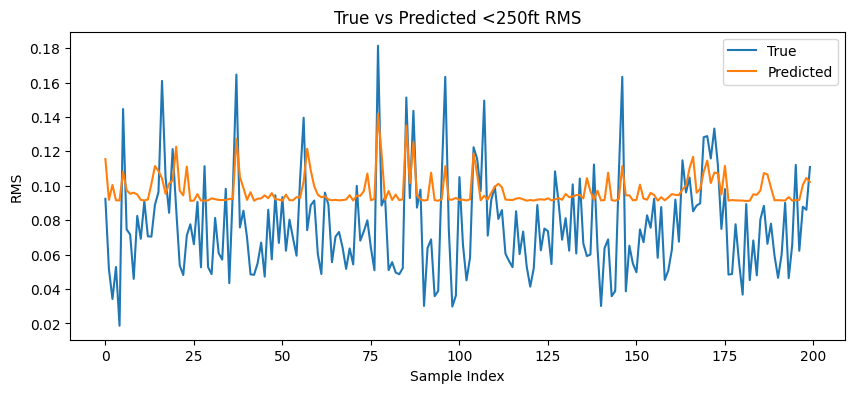

In [104]:
x_axis = np.arange(len(y_test))
plt.figure(figsize=(10,4))
plt.plot(x_axis[:200], y_test[:200], label="True")
plt.plot(x_axis[:200], y_pred_new[:200], label="Predicted")
plt.title('True vs Predicted <250ft RMS')
plt.xlabel('Sample Index')
plt.ylabel('RMS')
plt.legend()
plt.show()

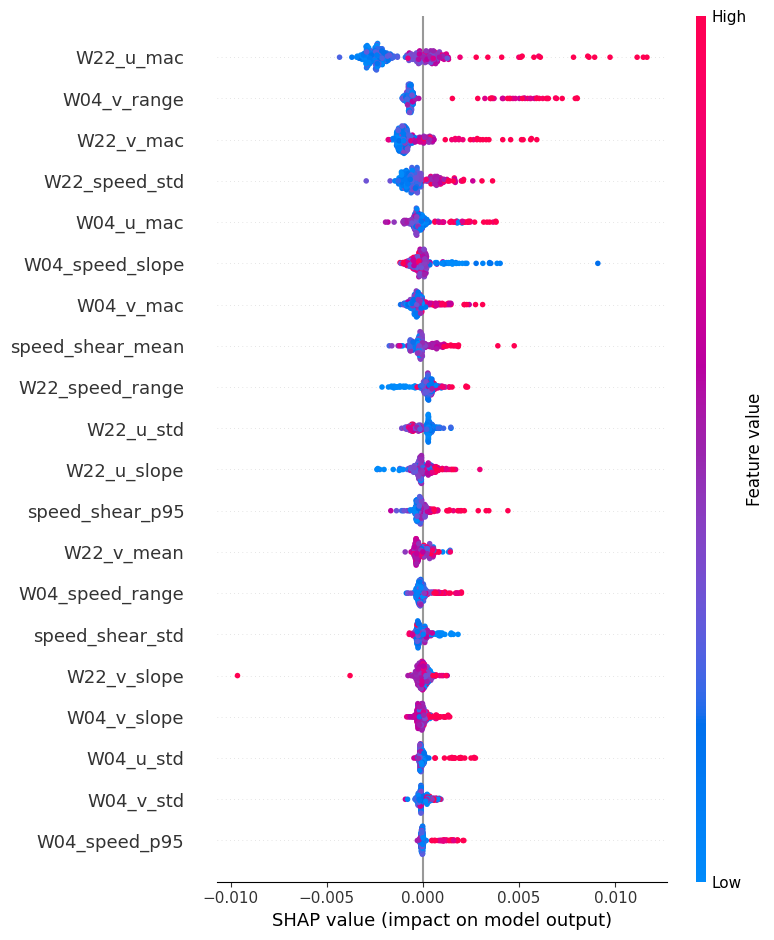

In [63]:
shap_values_new = shap.TreeExplainer(model_new).shap_values(X_val)
shap.summary_plot(shap_values_new, X_val, plot_type="dot")

Combination model

In [102]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────

SPIKE_PERCENTILE = 70                # top X% of y_train are considered spikes
BLEND_SHARPNESS             = 10     # higher = harder switch between models
N_TRIALS                    = 30     # optuna trials per model
N_ESTIMATORS                = 5000   # trees per model
EARLY_STOPPING_ROUNDS       = 50
RANDOM_STATE                = 42

# Best params found by Optuna — paste results here to skip re-tuning
BEST_PARAMS_CLASSIFIER = {'max_depth': 4, 'learning_rate': 0.034575879047178036, 'subsample': 0.6897782482740652, 'colsample_bytree': 0.6926504876850375}

BEST_PARAMS_MEAN = {'max_depth': 8, 'learning_rate': 0.01140631788738348, 'subsample': 0.603904781824156, 'colsample_bytree': 0.8510582023021905}

BEST_PARAMS_SPIKE = {'max_depth': 7, 'learning_rate': 0.037336170270069094, 'subsample': 0.6400568787844034, 'colsample_bytree': 0.7015833093192322}

# Set to True to skip Optuna and use BEST_PARAMS above directly
SKIP_OPTUNA = True

R²   (blend): 0.2752
MAPE (blend): 0.2841

--- Spike samples only (top 15%) ---
R² (blend):  -0.6611


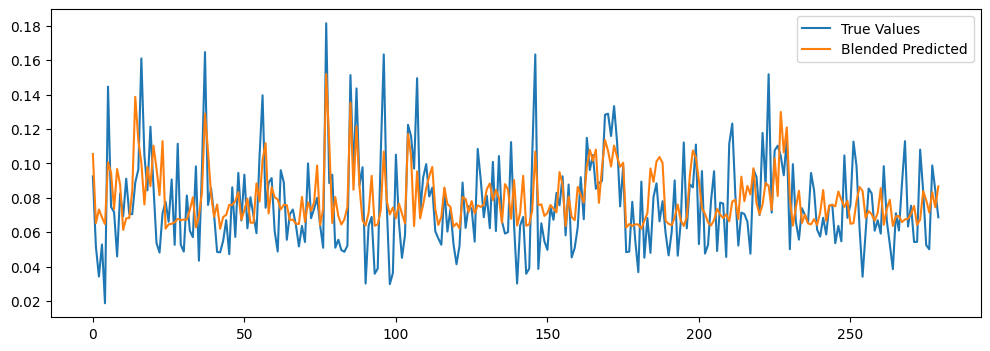

In [110]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LogisticRegression
import optuna

# --- Define spike threshold ---
SPIKE_THRESHOLD = np.percentile(y_train, SPIKE_PERCENTILE)  # tune this

# --- Labels for classifier ---
spike_train = (y_train > SPIKE_THRESHOLD).astype(int)
spike_val   = (y_val   > SPIKE_THRESHOLD).astype(int)
spike_test  = (y_test  > SPIKE_THRESHOLD).astype(int)


# ── 1. SPIKE CLASSIFIER ──────────────────────────────────────────────────────

def objective_classifier(trial):
    params = {
        "n_estimators":     5000,
        "max_depth":        trial.suggest_int("max_depth", 2, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective":        "binary:logistic",
        "eval_metric":      "auc",
        "random_state":     42,
        "scale_pos_weight": (1 - spike_train.mean()) / spike_train.mean(),  # handle class imbalance
    }
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train, spike_train, eval_set=[(X_val, spike_val)], verbose=False)
    prob = model.predict_proba(X_val)[:, 1]
    # Reward both precision on spikes and not over-triggering
    from sklearn.metrics import roc_auc_score
    return roc_auc_score(spike_val, prob)

if SKIP_OPTUNA:
    best_params = BEST_PARAMS_CLASSIFIER
else:
    study_clf = optuna.create_study(direction="maximize")
    study_clf.optimize(objective_classifier, n_trials=30)
    best_params = study_clf.best_params

classifier = xgb.XGBClassifier(
    **best_params,
    n_estimators=5000,
    early_stopping_rounds=50,
    scale_pos_weight=(1 - spike_train.mean()) / spike_train.mean(),
)
classifier.fit(X_train, spike_train, eval_set=[(X_val, spike_val)], verbose=False)


# ── 2. MEAN MODEL (normal samples only) ──────────────────────────────────────

mask_train_normal = spike_train == 0
mask_val_normal   = spike_val   == 0

def objective_mean(trial):
    params = {
        "n_estimators":     5000,
        "max_depth":        trial.suggest_int("max_depth", 2, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective":        "reg:squarederror",
        "eval_metric":      "rmse",
        "random_state":     42,
    }
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(
        X_train[mask_train_normal], y_train[mask_train_normal],
        eval_set=[(X_val[mask_val_normal], y_val[mask_val_normal])],
        verbose=False
    )
    y_pred = model.predict(X_val[mask_val_normal])
    return r2_score(y_val[mask_val_normal], y_pred)

if SKIP_OPTUNA:
    best_params_mean = BEST_PARAMS_MEAN
else:
    study_mean = optuna.create_study(direction="maximize")
    study_mean.optimize(objective_mean, n_trials=30)
    best_params_mean = study_mean.best_params

model_mean = xgb.XGBRegressor(**best_params_mean, n_estimators=5000, early_stopping_rounds=50)
model_mean.fit(
    X_train[mask_train_normal], y_train[mask_train_normal],
    eval_set=[(X_val[mask_val_normal], y_val[mask_val_normal])],
    verbose=False
)


# ── 3. SPIKE MODEL (spike samples only, weighted) ────────────────────────────

mask_train_spike = spike_train == 1
mask_val_spike   = spike_val   == 1

def objective_spike(trial):
    params = {
        "n_estimators":     5000,
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective":        "reg:squarederror",
        "eval_metric":      "rmse",
        "random_state":     42,
    }
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    # Weight by how extreme the spike is
    spike_weights = y_train[mask_train_spike] / y_train[mask_train_spike].mean()
    model.fit(
        X_train[mask_train_spike], y_train[mask_train_spike],
        sample_weight=spike_weights,
        eval_set=[(X_val[mask_val_spike], y_val[mask_val_spike])],
        verbose=False
    )
    y_pred = model.predict(X_val[mask_val_spike])
    return r2_score(y_val[mask_val_spike], y_pred)

if SKIP_OPTUNA:
    best_params_spike = BEST_PARAMS_SPIKE
else:
    study_spike = optuna.create_study(direction="maximize")
    study_spike.optimize(objective_spike, n_trials=30)
    best_params_spike = study_spike.best_params

model_spike = xgb.XGBRegressor(**best_params_spike, n_estimators=5000, early_stopping_rounds=50)
spike_weights = y_train[mask_train_spike] / y_train[mask_train_spike].mean()
model_spike.fit(
    X_train[mask_train_spike], y_train[mask_train_spike],
    sample_weight=spike_weights,
    eval_set=[(X_val[mask_val_spike], y_val[mask_val_spike])],
    verbose=False
)


# ── 4. BLEND PREDICTIONS ─────────────────────────────────────────────────────

def predict_blend(X, blend_sharpness=10):
    spike_prob  = classifier.predict_proba(X)[:, 1]  # 0–1 probability of being a spike
    pred_mean   = model_mean.predict(X)
    pred_spike  = model_spike.predict(X)

    # Soft blend: weight = sigmoid-sharpened spike probability
    # blend_sharpness controls how hard the switch is (higher = more binary)
    weight = 1 / (1 + np.exp(-blend_sharpness * (spike_prob - 0.5)))

    return (1 - weight) * pred_mean + weight * pred_spike

y_pred_blend = predict_blend(X_test, BLEND_SHARPNESS)

print(f"R²   (blend): {r2_score(y_test, y_pred_blend):.4f}")
print(f"MAPE (blend): {mean_absolute_percentage_error(y_test, y_pred_blend):.4f}")

# Compare spike-specific performance
print(f"\n--- Spike samples only (top 15%) ---")
print(f"R² (blend):  {r2_score(y_test[spike_test==1], y_pred_blend[spike_test==1]):.4f}")

x_axis = np.arange(len(y_test))
plt.figure(figsize=(12,4))
plt.plot(x_axis[:300], y_test[:300], label="True Values")
plt.plot(x_axis[:300], y_pred_blend[:300], label="Blended Predicted")
plt.legend()
plt.show()

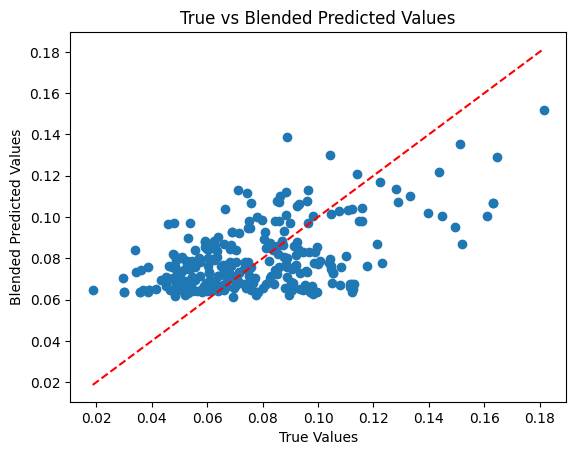

In [108]:
plt.plot(y_test, y_pred_blend, 'o')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Values')
plt.ylabel('Blended Predicted Values')
plt.title('True vs Blended Predicted Values')
plt.show()
